In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv('heart.csv')

In [6]:
print("Data loaded!")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Data loaded!
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Shape: (918, 12)

Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [7]:
print("\n=== INFO ===")
print(df.info())

print("\n=== DESCRIBE ===")
print(df.describe())


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

=== DESCRIBE ===
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.39

In [8]:
print("\n=== Heart Disease Distribution ===")
print(df['HeartDisease'].value_counts())



=== Heart Disease Distribution ===
HeartDisease
1    508
0    410
Name: count, dtype: int64


Text(0, 0.5, 'Count')

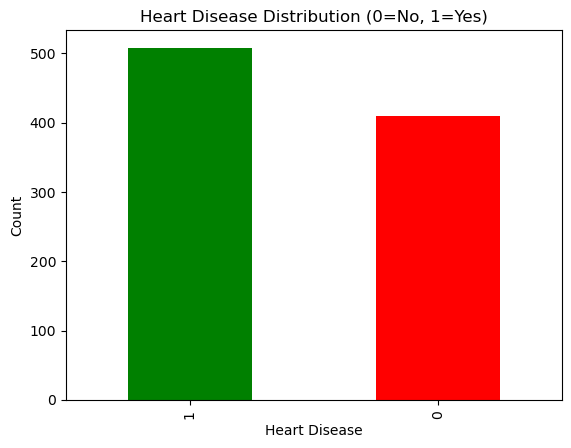

In [9]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Heart Disease Distribution (0=No, 1=Yes)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

In [10]:
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [11]:
print(f"\nDuplicates: {df.duplicated().sum()}")



Duplicates: 0


In [12]:
print(f"\nNull Values:\n{df.isnull().sum()}")



Null Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


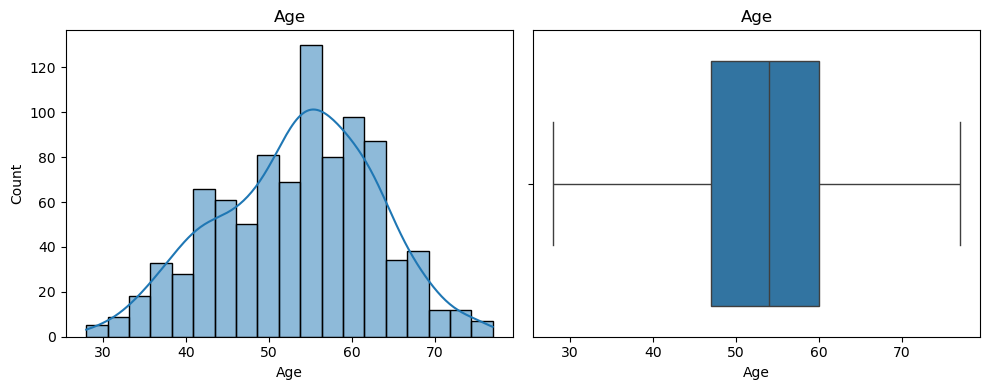

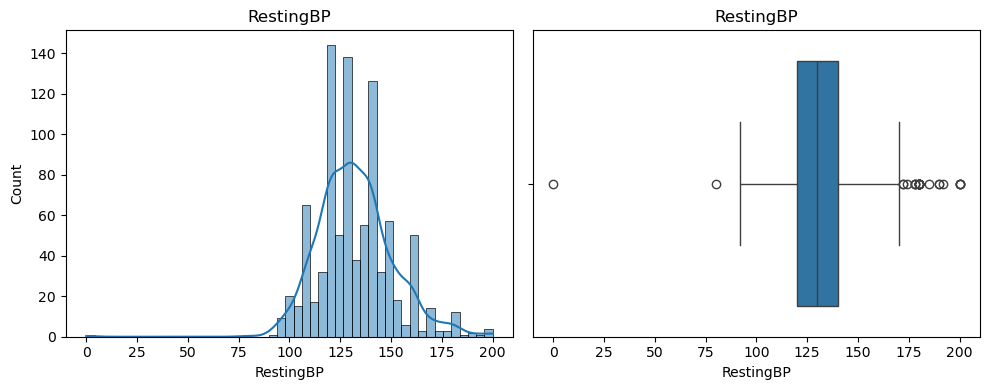

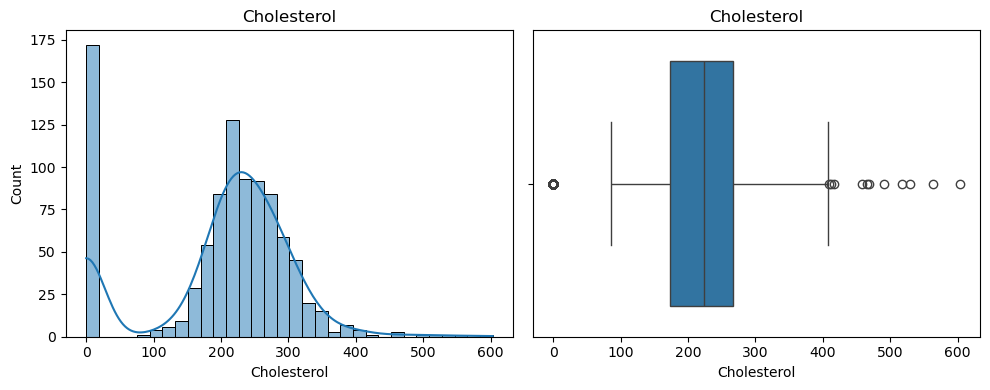

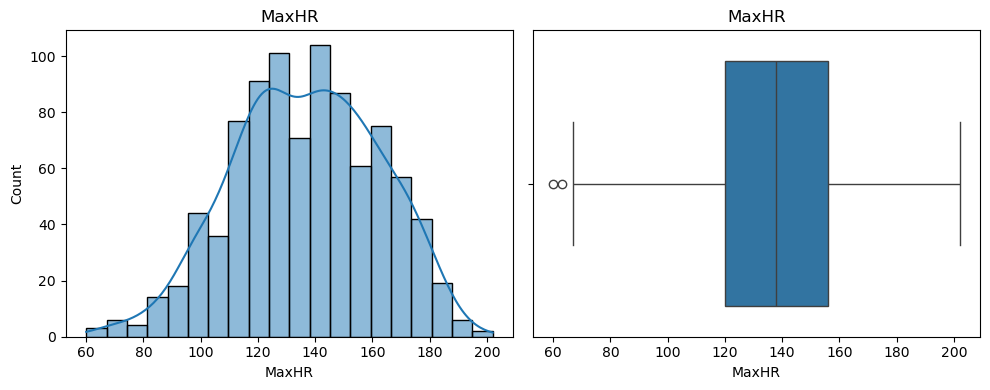

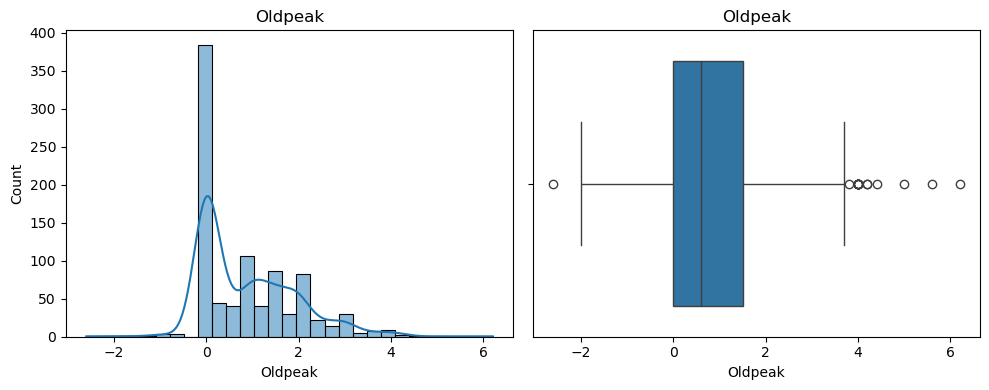

In [13]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for col in num_cols:

    plt.figure(figsize=(10,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(col)

    plt.tight_layout()
    plt.show()

In [14]:
print("\nRestingBP = 0")
print((df["RestingBP"] == 0).sum())

print("\nCholesterol = 0")
print((df["Cholesterol"] == 0).sum())



RestingBP = 0
1

Cholesterol = 0
172


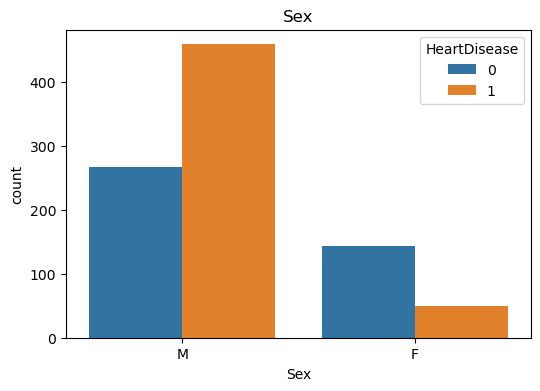

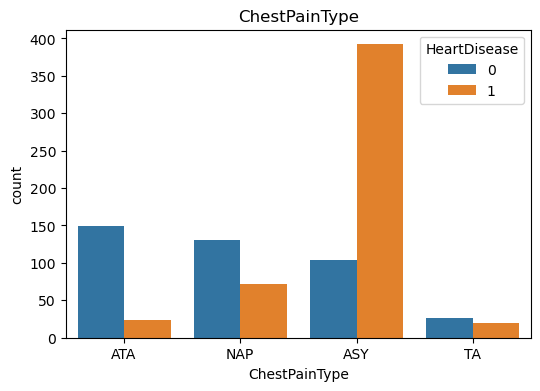

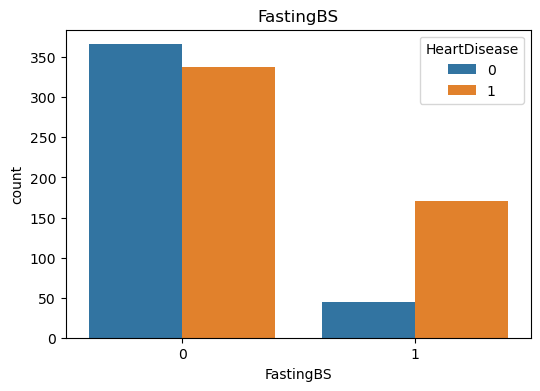

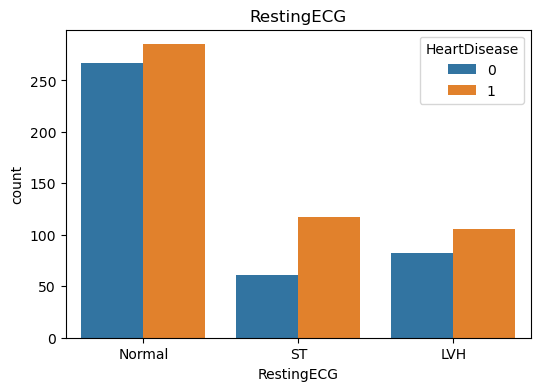

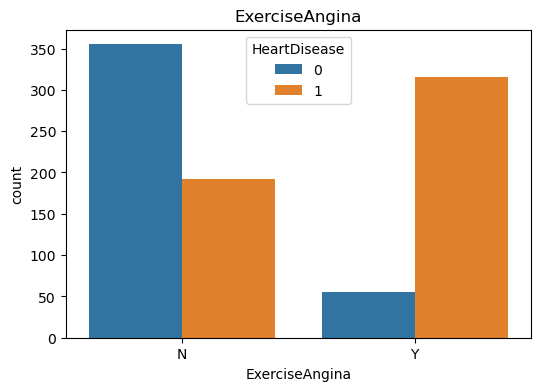

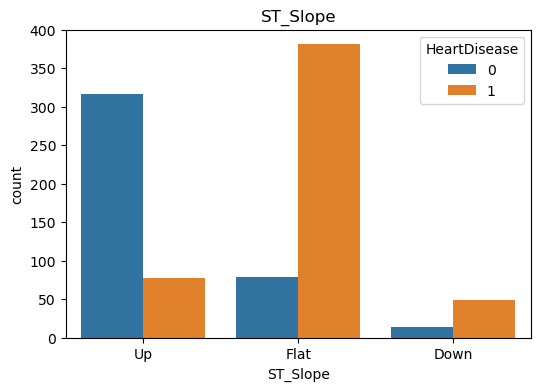

In [15]:
cat_cols = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df["HeartDisease"])
    plt.title(col)
    plt.show()

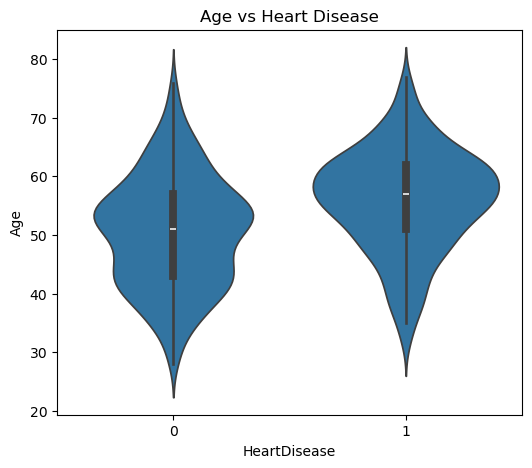

In [16]:
plt.figure(figsize=(6,5))
sns.violinplot(x=df["HeartDisease"], y=df["Age"])
plt.title("Age vs Heart Disease")
plt.show()

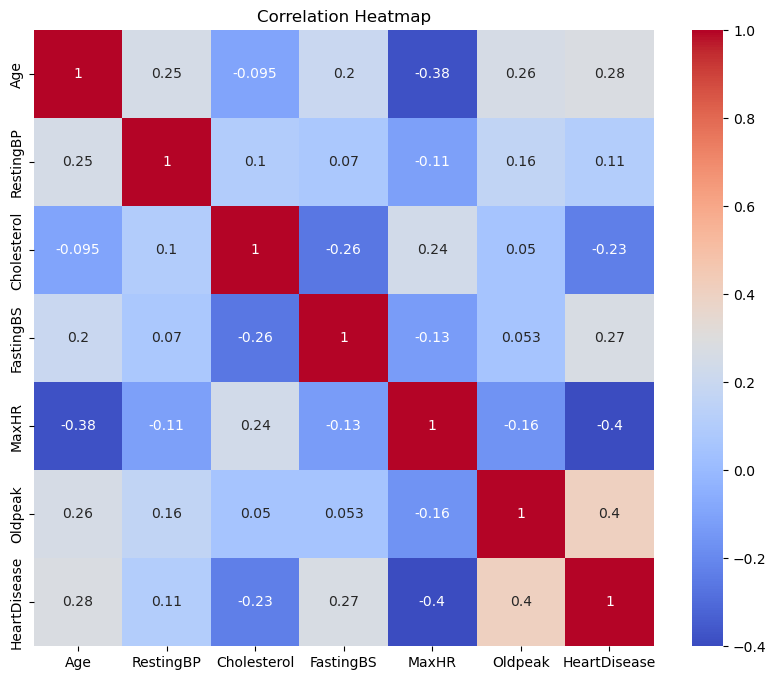


EDA Completed!


In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\nEDA Completed!")

In [18]:
# ============================================================
# STEP 3: DATA CLEANING
# ============================================================

# Replace impossible values (0) with mean

# Cholesterol
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)

# Resting Blood Pressure
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

print("\nAfter Cleaning")
print("Cholesterol zeros:", (df["Cholesterol"] == 0).sum())
print("RestingBP zeros:", (df["RestingBP"] == 0).sum())



After Cleaning
Cholesterol zeros: 0
RestingBP zeros: 0


In [19]:

# ============================================================
# STEP 4: ENCODING
# ============================================================

# Convert categorical values into numbers

df_encoded = pd.get_dummies(df, drop_first=True)

print("\nShape After Encoding")
print(df_encoded.shape)

print(df_encoded.head())


Shape After Encoding
(918, 16)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0               True          False 

In [20]:

# ============================================================
# STEP 5: FEATURE SCALING
# ============================================================

scaler = StandardScaler()

num_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("\nScaling Completed!")



Scaling Completed!


In [21]:
# ============================================================
# STEP 7: SAVE DATA
# ============================================================

df_encoded.to_csv("heart_preprocessed.csv", index=False)

print("\nPreprocessing Completed Successfully!")
print("Final Shape:", df_encoded.shape)
print("Dataset saved as heart_preprocessed.csv")


Preprocessing Completed Successfully!
Final Shape: (918, 16)
Dataset saved as heart_preprocessed.csv


In [22]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832529,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527192,-1.212922,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141317,0.719935,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303619,-0.574892,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.971022,-0.931438,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


In [23]:
import joblib

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

In [25]:
df_encoded = pd.get_dummies(df, columns=[
    'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'
])

In [26]:
print(df_encoded.columns.tolist())
print(df_encoded.shape)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
(918, 21)


In [27]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [30]:
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(kernel='rbf')
}

In [31]:
results = []

In [33]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    acc = round(accuracy_score(y_test, y_pred), 4)
    f1  = round(f1_score(y_test, y_pred), 4)
    results.append({'Model': name, 'Accuracy': acc, 'F1_Score': f1})
    print(f"{name:<25} | Accuracy: {acc} | F1: {f1}")

Logistic Regression       | Accuracy: 0.8641 | F1: 0.8792
KNN                       | Accuracy: 0.8533 | F1: 0.8696
Naive Bayes               | Accuracy: 0.837 | F1: 0.85
Decision Tree             | Accuracy: 0.8315 | F1: 0.8426
SVM                       | Accuracy: 0.8641 | F1: 0.8804


In [34]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)

In [35]:
print("\n--- Best Model ---")
print(results_df.iloc[0])


--- Best Model ---
Model       Logistic Regression
Accuracy                 0.8641
F1_Score                 0.8792
Name: 0, dtype: object


In [36]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

In [37]:
joblib.dump(best_model, 'knn_heart_model.pkl')

['knn_heart_model.pkl']

In [38]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [39]:
columns = X.columns.tolist()
joblib.dump(columns, 'columns.pkl')

print(f"\nSaved model: knn_heart_model.pkl")
print(f"Saved scaler: scaler.pkl")
print(f"Saved columns: columns.pkl ({len(columns)} features)")
print("Columns:", columns)


Saved model: knn_heart_model.pkl
Saved scaler: scaler.pkl
Saved columns: columns.pkl (20 features)
Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
